<a href="https://colab.research.google.com/github/adenikeadewumi/Quantum-Machine-Learning-QML-/blob/main/Quantum_computing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install the core qiskit library and the Aer simulator provider
%pip install qiskit qiskit-aer

# Install visualization tools (needed for drawing circuits)
%pip install qiskit[visualization] pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=a32b9a41dad570fffcd07546683994d23837fa3cf77f9dba0e3ec46341ad3d71
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [ ]:
%pip install qiskit-aer

Character printing

Quantum Computer says: Hello World!


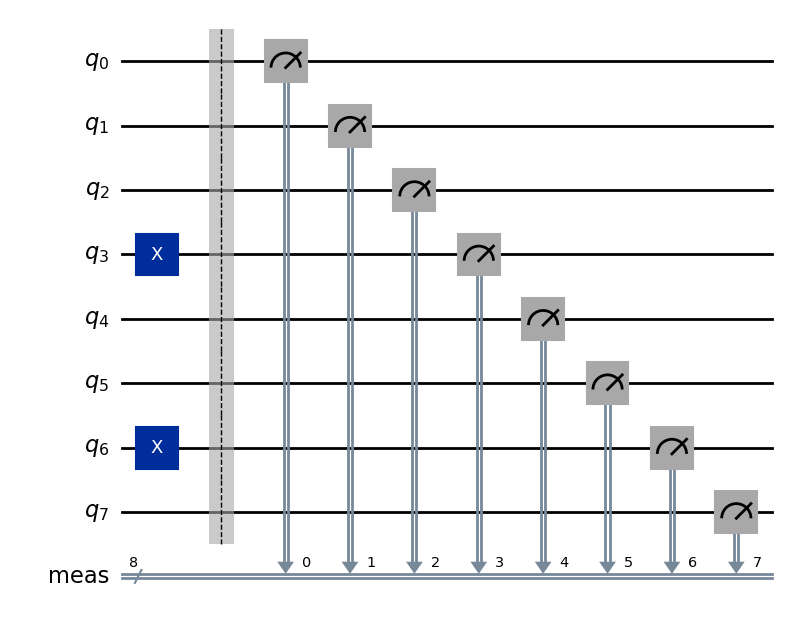

In [ ]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import Aer
#H= 01001000
qc= QuantumCircuit(8)
qc.x(3)
qc.x(6)

qc.measure_all()

# Run simulator
sim = Aer.get_backend('qasm_simulator')
counts = sim.run(qc).result().get_counts()

# Translate binary back to character
binary_result = list(counts.keys())[0]
ascii_char = chr(int(binary_result, 2))

print(f"Quantum Computer says: {ascii_char}ello World!")
qc.draw("mpl")


Printing random characters using superposition

Quantum Computer says: @ello World!


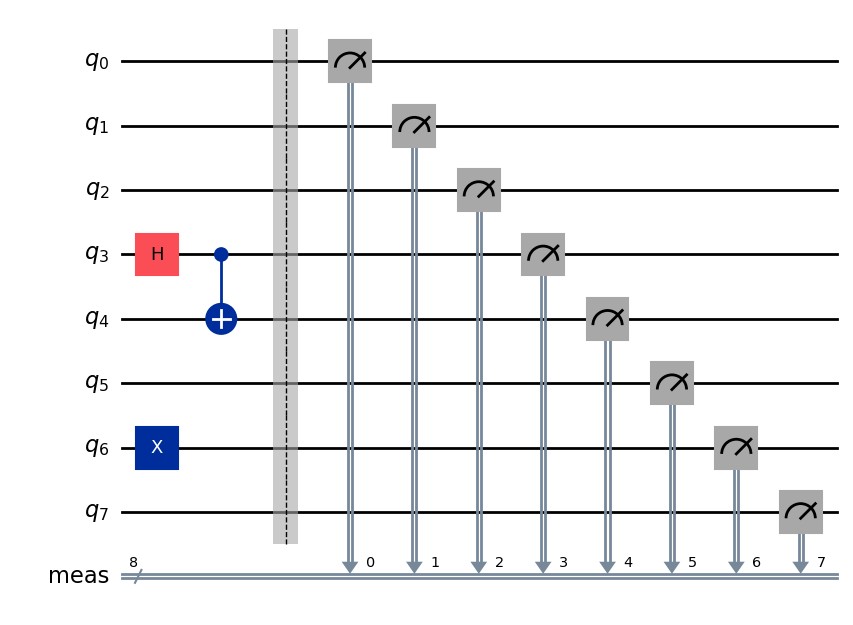

In [ ]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import Aer
#H= 01001000
qc1= QuantumCircuit(8)
qc1.h(3)
qc1.cx(3, 4)
qc1.x(6) # Bit for 64
# 64 + 8 = 72 ('H')

qc1.measure_all()

# Run simulator
sim = Aer.get_backend('qasm_simulator')
job= sim.run(qc1, steps= 1000)
counts = job.result().get_counts()

# Translate binary back to character
binary_result = list(counts.keys())[0]
ascii_char = chr(int(binary_result, 2))

print(f"Quantum Computer says: {ascii_char}ello World!")
qc1.draw("mpl")

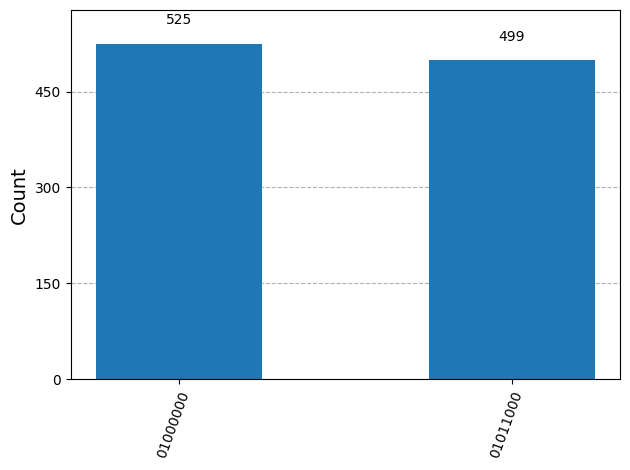

In [ ]:
#print probability of occurence

plot_histogram(counts)

Coin flip

In [ ]:
qc2= QuantumCircuit(1,1)
qc2.h(0)
qc2.measure(0,0)

job2= sim.run(qc2, shots= 1)
counts = job2.result().get_counts()

print(counts)
# Translate binary back to character
binary_value= list(counts.keys())[0]

print(binary_value)

if binary_value == '0':
  print("Heads")
else:
  print("Tails")

{'1': 1}
1
Tails


Oracle

Deutsch algoorithm

In [ ]:

def constant_oracle(n):
    # n is the number of input qubits; we add 1 for the ancilla
    oracle_qc = QuantumCircuit(n + 1)

    # Randomly decide if the constant output is 0 or 1
    import random
    if random.randint(0, 1) == 1:
        # If output is 1, we flip the ancilla qubit (the last qubit)
        oracle_qc.x(n)

    oracle_qc.name = "Constant Oracle"
    return oracle_qc

In [ ]:
def balanced_oracle(n):
    oracle_qc = QuantumCircuit(n + 1)

    # Place a CNOT gate from each input qubit to the ancilla
    # This ensures that the state of the ancilla depends on the inputs
    for qubit in range(n):
        oracle_qc.cx(qubit, n)

    # Optional: Add X-gates to some qubits before/after to vary the 0/1 pattern
    # But CNOTs alone are sufficient to make it balanced.

    oracle_qc.name = "Balanced Oracle"
    return oracle_qc

Visualizing Constant Oracle:


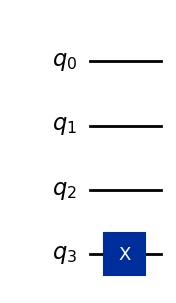


Visualizing Balanced Oracle:


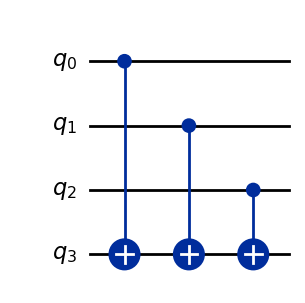

In [ ]:
n_bits = 3 # Let's use 3 bits for the input register

# Create and draw the Constant Oracle
c_oracle = constant_oracle(n_bits)
print("Visualizing Constant Oracle:")
display(c_oracle.draw(output='mpl'))

# Create and draw the Balanced Oracle
b_oracle = balanced_oracle(n_bits)
print("\nVisualizing Balanced Oracle:")
display(b_oracle.draw(output='mpl'))

In [ ]:
qc4= QuantumCircuit(3,2)

#Apply hadamard to the input qubits
qc4.h(0)
qc4.h(1)
qc4.cx()


[0, 1, 2, 3]

--- Full Circuit for Constant Oracle ---


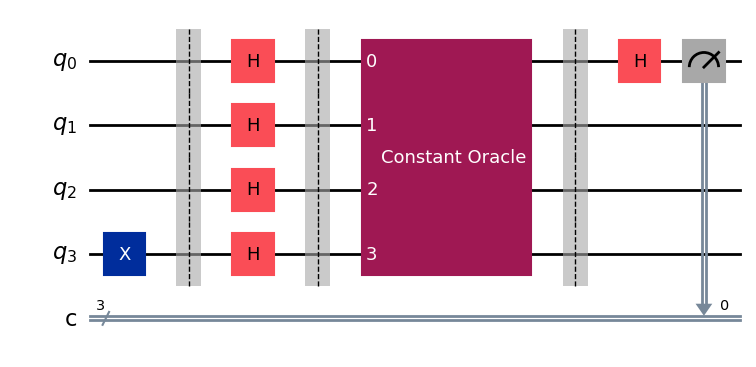

Result: 000 -> The function is constant
[0, 1, 2, 3]

--- Full Circuit for Balanced Oracle ---


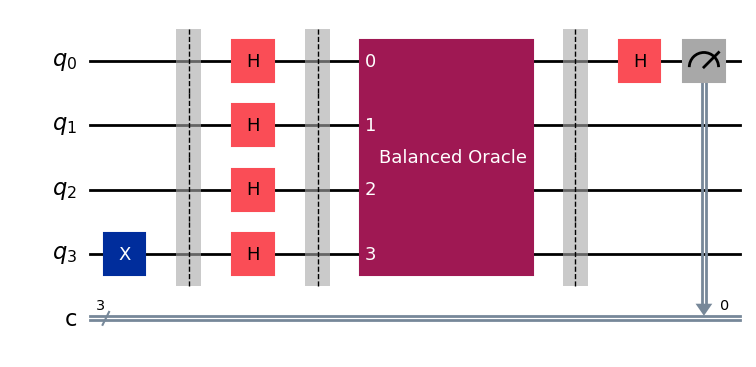

Result: 001 -> The function is balanced


In [ ]:
from qiskit_aer import Aer

def run_deutsch_algorithm(oracle, n):
    # Task 2: Construction
    # 2 qubits, 1 classical bit for the result
    qc = QuantumCircuit(n+1, n)

    # 1. Initialize ancilla to |1>
    qc.x(n)
    qc.barrier() # Visual separator

    # 2. Apply H-gates to create superposition
    for qubit in range(n):
        qc.h(qubit)
    qc.h(n)
    qc.barrier()

    # 3. Append the Oracle
    lst=[]
    for i in range(n+1):
        lst.append(i)
    print(lst)
    qc.append(oracle, lst)
    qc.barrier()

    # 4. Final H-gate on input qubit to trigger interference
    qc.h(0)

    # Task 3: Measurement
    qc.measure(0, 0)

    # Draw the full circuit
    print(f"\n--- Full Circuit for {oracle.name} ---")
    display(qc.draw('mpl'))

    # Execute
    decomposed_qc = qc.decompose()
    sim = Aer.get_backend('qasm_simulator')
    result = sim.run(decomposed_qc, shots=1).result()
    answer = list(result.get_counts().keys())[0]

    # Result Analysis
    if '01' in answer:
        print(f"Result: {answer} -> The function is balanced")
    else:
        print(f"Result: {answer} -> The function is constant")

# --- EXECUTION ---
# Test 1: Constant
run_deutsch_algorithm(constant_oracle(3),3)

# Test 2: Balanced
run_deutsch_algorithm(balanced_oracle(3),3)

Quantum Superposition Visualizer

Qubit in its natural resting state:


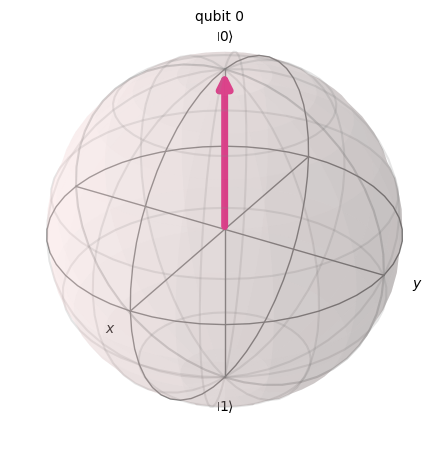

In [ ]:
from qiskit.visualization import plot_bloch_multivector
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt


qc5= QuantumCircuit(1)
state = Statevector.from_instruction(qc5)

print("Qubit in its natural resting state:")
plot_bloch_multivector(state)

Qubit after x gate operation:


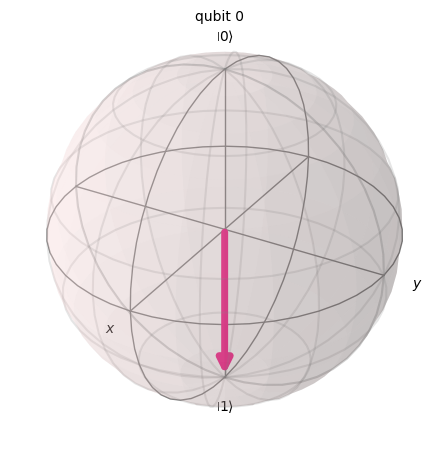

In [ ]:
qc5.x(0)
state = Statevector.from_instruction(qc5)

print("Qubit after x gate operation:")
plot_bloch_multivector(state)

Qubit after x gate operation:


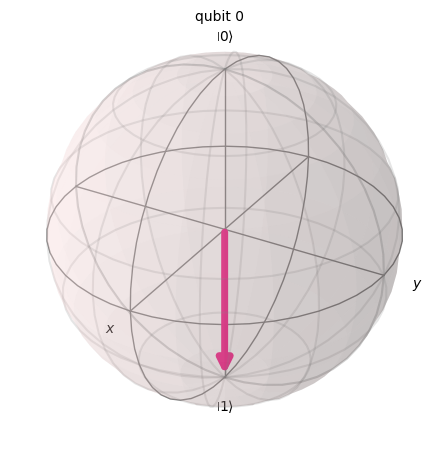

In [ ]:
qc5.y(0)
state = Statevector.from_instruction(qc5)

print("Qubit after y gate operation:")
plot_bloch_multivector(state)

Qubit after x gate operation:


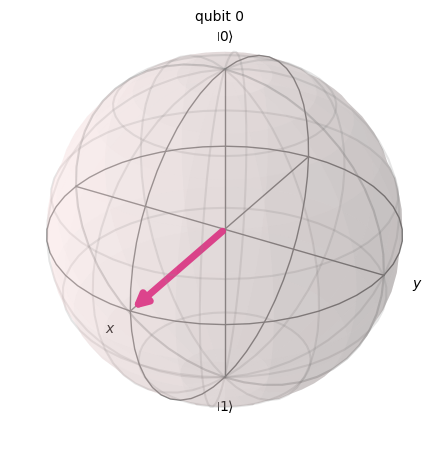

In [ ]:
qc5.h(0)
state = Statevector.from_instruction(qc5)

print("Qubit after h gate operation:")
plot_bloch_multivector(state)

In [ ]:
def visualize_gates(gate_list):
  circuit= QuantumCircuit(1)
  for gate in gate_list:
    if gate.lower() == 'x':
      circuit.x(0)
    elif gate.lower() == 'y':
      circuit.y(0)
    elif gate.lower() == 'h':
      circuit.h(0)
    elif gate.lower()== 'z':
      circuit.z(0)
    else:
      print("Invalid gate input")
    state= Statevector.from_instruction(circuit)
    display(plot_bloch_multivector(state))

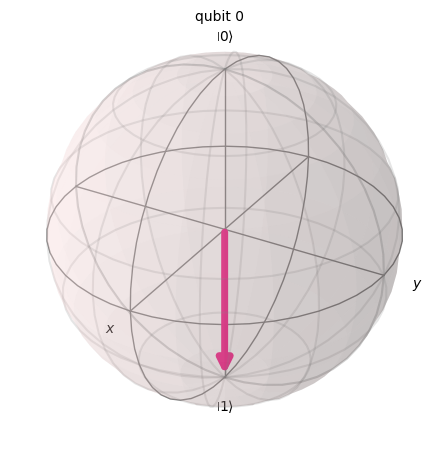

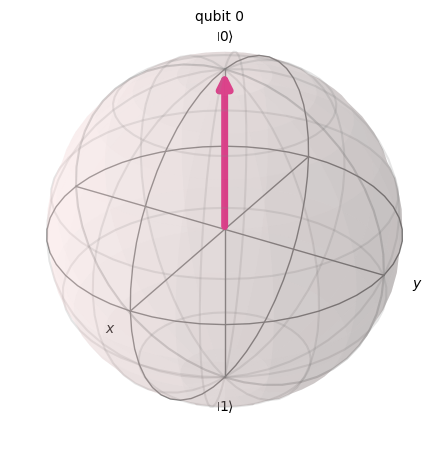

In [ ]:
visualize_gates(["x", "y"])

Bell state entanglement simulation

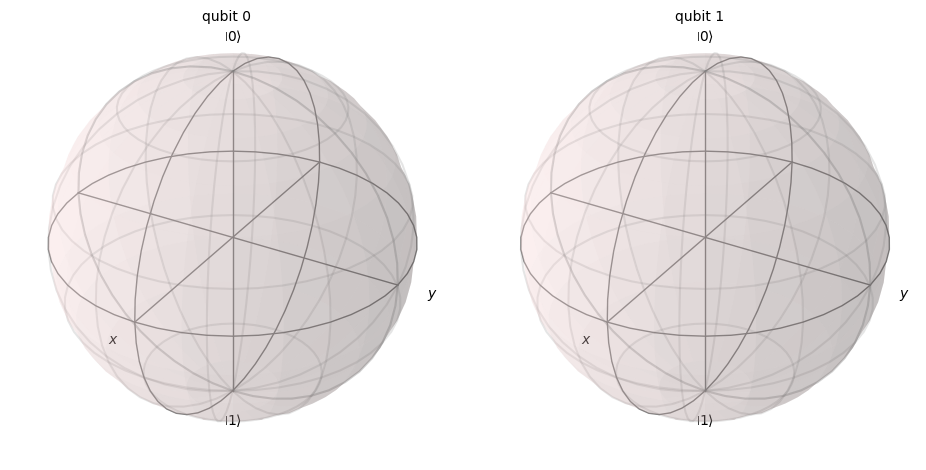

{'11': 495, '00': 505}


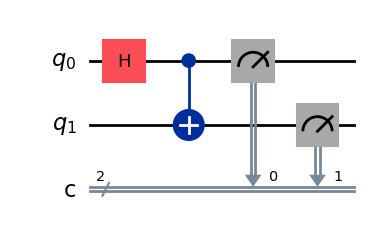

In [ ]:
qc6= QuantumCircuit(2,2)
#qc6.x(0)
#qc6.x(1)
qc6.h(0)
qc6.cx(0,1)
state= Statevector.from_instruction(qc6)

display(plot_bloch_multivector(state))

qc6.measure([0,1],[0,1])

sim= Aer.get_backend('qasm_simulator')
job= sim.run(qc6, shots= 1000)
counts= job.result().get_counts()
print(counts)
qc6.draw('mpl')




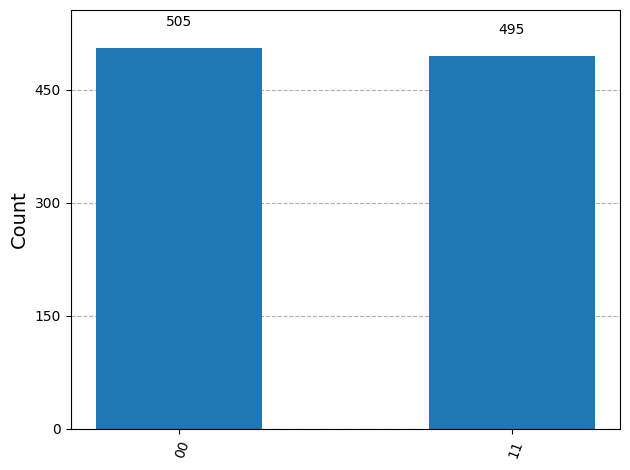

In [ ]:
plot_histogram(counts)

Quantum Teleportation Simulation

['01']


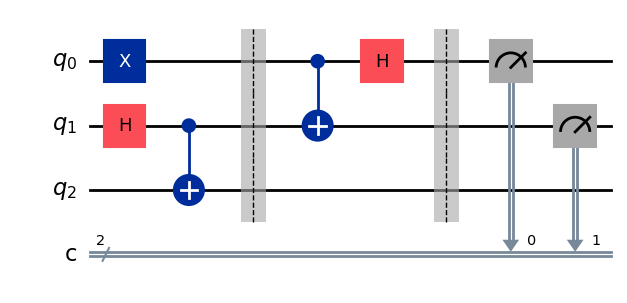

In [ ]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import Aer

qc7= QuantumCircuit(3,2)

##Entangle states of sender and reciever
qc7.h(1)
qc7.cx(1,2)

#Make information bit uniquue by flippling about the x axis
qc7.x(0)

qc7.barrier()

#entangle state of bit of info and sender
qc7.cx(0,1)
qc7.h(0)

qc7.barrier()

qc7.measure([0,1],[0,1])
# Execute
decomposed_qc = qc7.decompose()
sim = Aer.get_backend('qasm_simulator')
result = sim.run(decomposed_qc, shots=1).result()
answer = list(result.get_counts())#.keys())#[0]
print(answer)
#if

qc7.draw("mpl")

Tic tac toe

In [ ]:
from qiskit import QuantumCircuit
# Change your import to this:
from qiskit.primitives import StatevectorSampler as Sampler

def display_board(state_bits):
    """
    Converts a bitstring into a 3x3 grid.
    Note: Qiskit bitstrings are little-endian (right-to-left),
    so we reverse it to match index 0-8.
    """
    # Reverse to make index 0 the first element
    bits = state_bits[::-1]
    board = [ 'X' if bits[i] == '1' else '.' for i in range(9)]

    print("\n--- Current Board State ---")
    print(f" {board[0]} | {board[1]} | {board[2]} ")
    print("-----------")
    print(f" {board[3]} | {board[4]} | {board[5]} ")
    print("-----------")
    print(f" {board[6]} | {board[7]} | {board[8]} ")
    print("---------------------------\n")

def play_quantum_ttt():
    # Initialize 9 qubits (one for each square)
    qc = QuantumCircuit(9)
    moves_made = 0
    current_player = "Alice (X)"

    print("Welcome to Quantum Tic-Tac-Toe!")
    print("Squares are indexed 0-8 (Top-left to Bottom-right)")

    while moves_made < 9:
        print(f"Turn {moves_made + 1}: {current_player}")
        try:
            choice = input("Type 'c' (Classical) or 'q' (Quantum): ").lower().strip()

            if choice == 'c':
                sq = int(input("Enter square (0-8): "))
                qc.x(sq)
                moves_made += 1
            elif choice == 'q':
                sq1 = int(input("Enter first square (0-8): "))
                sq2 = int(input("Enter second square (0-8): "))
                # Create entanglement: Square 1 and Square 2 share one move
                qc.h(sq1)
                qc.cx(sq1, sq2)
                moves_made += 1
            else:
                print("Invalid choice, try again.")
                continue
        except ValueError:
            print("Please enter valid numbers for the squares.")
            continue

        # Swap players
        current_player = "Bob (O)" if "Alice" in current_player else "Alice (X)"

    # --- THE COLLAPSE ---
    print("\nBoard is full! Measuring the quantum state...")
    qc.measure_all()

    # Use the modern Sampler
    sampler = Sampler()
    job = sampler.run(qc)
    result = job.result()

    # Extract the most likely bitstring
    # binary_probabilities() returns a dict like {'0101...': 1.0}
    probabilities = result.quasi_dists[0].binary_probabilities()
    final_bitstring = max(probabilities, key=probabilities.get)

    display_board(final_bitstring)
    print("Game Over! If a square has an 'X', it was successfully occupied.")

if __name__ == "__main__":
    play_quantum_ttt()

Welcome to Quantum Tic-Tac-Toe!
Squares are indexed 0-8 (Top-left to Bottom-right)
Turn 1: Alice (X)
Type 'c' (Classical) or 'q' (Quantum): c
Enter square (0-8): 0
Turn 2: Bob (O)
Type 'c' (Classical) or 'q' (Quantum): c
Enter square (0-8): 4
Turn 3: Alice (X)
Type 'c' (Classical) or 'q' (Quantum): q
Enter first square (0-8): 1
Enter second square (0-8): 2
Turn 4: Bob (O)
Type 'c' (Classical) or 'q' (Quantum): q
Enter first square (0-8): 1
Enter second square (0-8): 7
Turn 5: Alice (X)
Type 'c' (Classical) or 'q' (Quantum): 6
Invalid choice, try again.
Turn 5: Alice (X)
Type 'c' (Classical) or 'q' (Quantum): c
Enter square (0-8): 6
Turn 6: Bob (O)
Type 'c' (Classical) or 'q' (Quantum): c
Enter square (0-8): 5
Turn 7: Alice (X)
Type 'c' (Classical) or 'q' (Quantum): q
Enter first square (0-8): 3
Enter second square (0-8): 6
Turn 8: Bob (O)
Type 'c' (Classical) or 'q' (Quantum): q
Enter first square (0-8): 5
Enter second square (0-8): 8
Turn 9: Alice (X)
Type 'c' (Classical) or 'q' (Quan

ValueError: An invalid Sampler pub-like was given (<class 'qiskit._accelerate.circuit.CircuitInstruction'>). If you want to run a single circuit, you need to wrap it with `[]` like `sampler.run([circuit])` instead of `sampler.run(circuit)`.